           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 

/tmp/ipython-input-351204060.py:16: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df[date_col] = pd.to_datetime(df[date_col])
/tmp/ipython-input-351204060.py:24: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")[rate_col]


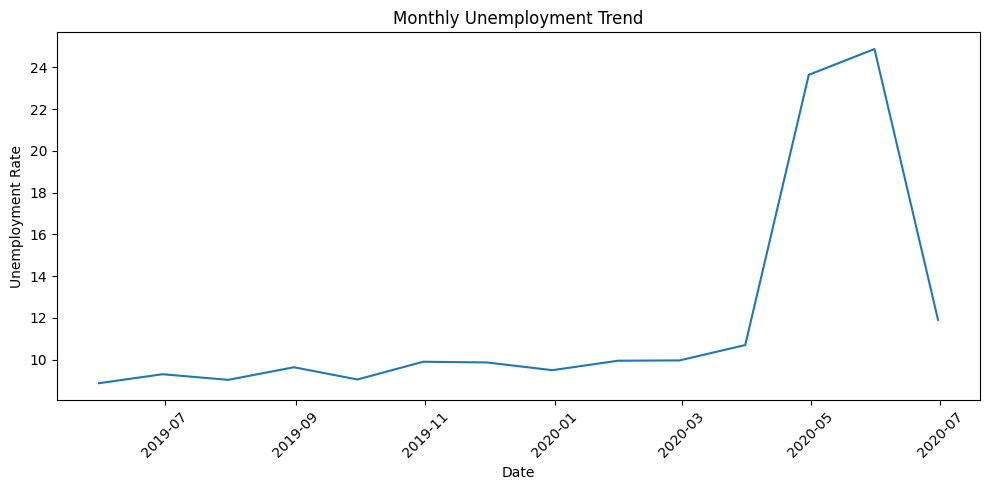

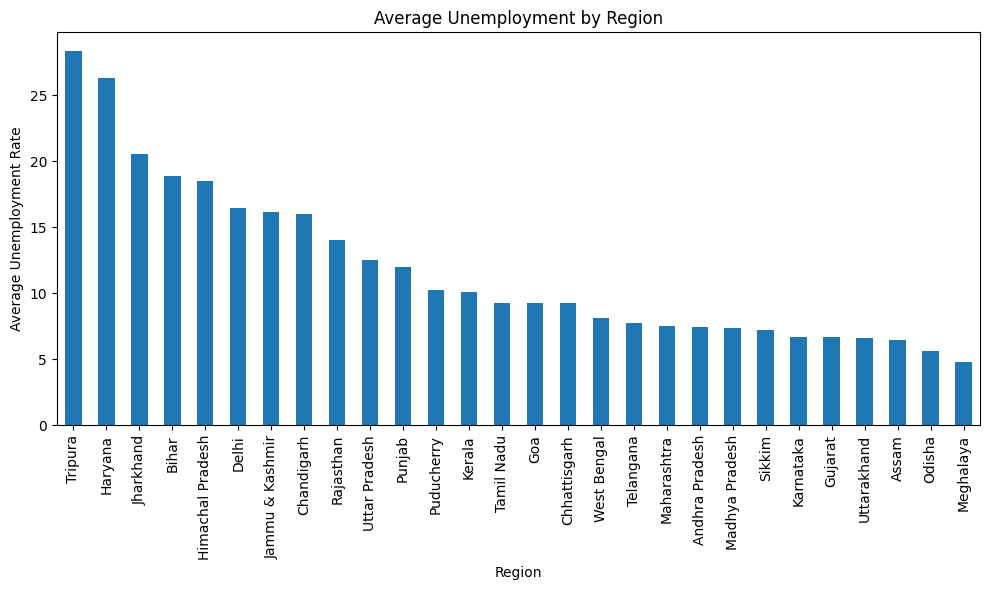

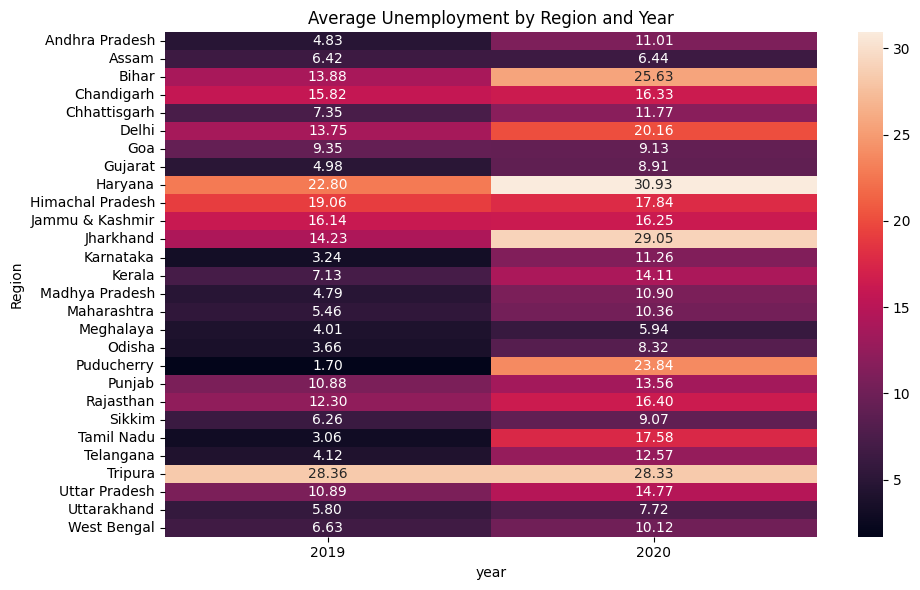

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("Unemployment in India.csv")

df.columns = df.columns.str.strip()

print(df.head())
print(df.info())

date_col = "Date"
rate_col = "Estimated Unemployment Rate (%)"
region_col = "Region"

df[date_col] = pd.to_datetime(df[date_col])
df = df.dropna(subset=[date_col, rate_col])

print(df.isna().sum())
print(df[rate_col].describe())

df_monthly = (
    df.set_index(date_col)
    .resample("M")[rate_col]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(df_monthly[date_col], df_monthly[rate_col])
plt.title("Monthly Unemployment Trend")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

region_avg = (
    df.groupby(region_col)[rate_col]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
region_avg.plot(kind="bar")
plt.title("Average Unemployment by Region")
plt.xlabel("Region")
plt.ylabel("Average Unemployment Rate")
plt.tight_layout()
plt.show()

df["year"] = df[date_col].dt.year

pivot = df.pivot_table(
    index=region_col,
    columns="year",
    values=rate_col,
    aggfunc="mean"
)

plt.figure(figsize=(10, 6))
sns.heatmap(pivot, annot=True, fmt=".2f")
plt.title("Average Unemployment by Region and Year")
plt.tight_layout()
plt.show()
